In [ ]:
from misc.dataset import get_data
from misc.helpers import normalizeRNA
from models.cncvae import CNCVAE
from models.dec import DEC
from models.metrics import calculate_metrics

data = get_data(clin_file='../Dataset/MetaSheet_1_4_17.csv', clinical_mode='full')
x_num = normalizeRNA(data['rnanp'])   # RNA-seq CPM, min-max scaled
x_bin = data['clin']                  # binary clinical/genotype dummies
print(x_num.shape, x_bin.shape, data['label_classes'])

ae = CNCVAE(input_size=x_num.shape[1] + x_bin.shape[1], ls=8)
ae.build_model()
ae.train(x_num, x_bin)

dec = DEC(ae, n_clusters=2)
y_pred, y_proba, centroids, z = dec.fit(x_num, x_bin, y=data['y'])

acc, ari, nmi = calculate_metrics(data['y'], y_pred)
print('acc={:.3f}  ari={:.3f}  nmi={:.3f}'.format(acc, ari, nmi))

In [ ]:
import os
import pandas as pd

run_dir = 'results/manual_run_17_2'
os.makedirs(run_dir, exist_ok=True)

ae.save_encoder(os.path.join(run_dir, 'encoder_cncvae.pt'))

emb = pd.DataFrame({'sample_id': data['sample_id']})
for j in range(z.shape[1]):
    emb['z{}'.format(j)] = z[:, j]
emb['mgs_level'] = data['label_classes'][data['y']]
emb.to_csv(os.path.join(run_dir, 'cncdec_latent_embedding.csv'), index=False)

import numpy as np
np.savez(os.path.join(run_dir, 'mgs_level.npz'),
         z=z, y_pred=y_pred, y_proba=y_proba, centroids=centroids,
         y=data['y'], sample_id=data['sample_id'], classes=data['label_classes'])
print('Saved to', run_dir)

In [ ]:
%pip install -q umap-learn

import numpy as np
import matplotlib.pyplot as plt
import umap

proj = umap.UMAP(n_components=2, random_state=5192).fit_transform(z)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for c in np.unique(y_pred):
    mask = y_pred == c
    axes[0].scatter(proj[mask, 0], proj[mask, 1], label=f'cluster {c}', alpha=0.7)
axes[0].set_title('CNC-DEC latent space (UMAP) - predicted clusters')
axes[0].legend()

for c, name in enumerate(data['label_classes']):
    mask = data['y'] == c
    axes[1].scatter(proj[mask, 0], proj[mask, 1], label=name, alpha=0.7)
axes[1].set_title('CNC-DEC latent space (UMAP) - true mgs_level')
axes[1].legend()
plt.tight_layout()
plt.show()

In [ ]:
ct = pd.crosstab(pd.Series(y_pred, name='cluster'),
                 pd.Series(data['label_classes'][data['y']], name='mgs_level'))
print(ct)

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(ct.values, cmap='Blues')
ax.set_xticks(range(len(ct.columns))); ax.set_xticklabels(ct.columns)
ax.set_yticks(range(len(ct.index))); ax.set_yticklabels(ct.index)
ax.set_xlabel('mgs_level'); ax.set_ylabel('cluster')
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        ax.text(j, i, ct.values[i, j], ha='center', va='center')
plt.colorbar(im)
plt.title('CNC-DEC cluster vs. mgs_level')
plt.show()

In [ ]:
plt.figure(figsize=(5, 4))
plt.hist(y_proba.max(axis=1), bins=20)
plt.xlabel('max soft-assignment probability')
plt.ylabel('# samples')
plt.title('CNC-DEC cluster assignment confidence')
plt.show()

In [1]:
# ---- Load a previously saved encoder checkpoint and warm-start it ----
from models.cncvae import load_cncvae_model
from misc.dataset import get_data
from misc.helpers import normalizeRNA
from models.cncvae import CNCVAE
from models.dec import DEC
from models.metrics import calculate_metrics
import umap
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd

data = get_data(clin_file='../Dataset/MetaSheet_1_4_17.csv', clinical_mode='full')
x_num = normalizeRNA(data['rnanp'])
x_bin = data['clin']
print(x_num.shape, x_bin.shape, data['label_classes'])

encoder_path = 'results/manual_run_17_2/encoder_cncvae.pt'  # <- point this at a saved checkpoint
ae_loaded = load_cncvae_model(encoder_path)  # build_model() + load_state_dict() + eval() already done
a = ae_loaded.args
print('Loaded: ds={} ls={} dropout={} act={} input_size={}'.format(
    a.ds, a.ls, a.dropout, a.act, a.input_size))

if a.input_size != x_num.shape[1] + x_bin.shape[1]:
    raise ValueError('Input width {} does not match checkpoint input_size {} - '
                      'check clinical_mode matches how this encoder was trained'.format(
                          x_num.shape[1] + x_bin.shape[1], a.input_size))

(166, 81) (166, 16) ['MGS1' 'MGS4']
Loaded: ds=64 ls=8 dropout=0.2 act=elu input_size=97


In [2]:
# ---- Cluster the loaded encoder's latent space directly ----
# DEC.fit() fine-tunes the encoder jointly with the clustering head as part of
# clustering itself, so this does NOT require the separate standalone
# fine-tune cell below - that one is only for extra pretraining epochs on the
# encoder alone before clustering, and is optional.
dec_loaded = DEC(ae_loaded, n_clusters=2)
y_pred_loaded, y_proba_loaded, centroids_loaded, z_loaded = dec_loaded.fit(x_num, x_bin, y=data['y'])

acc, ari, nmi = calculate_metrics(data['y'], y_pred_loaded)
print('acc={:.3f}  ari={:.3f}  nmi={:.3f}'.format(acc, ari, nmi))

Iter 0: acc = 0.68675, nmi = 0.10182, ari = 0.09013 ; loss=0.00000
Iter 50: acc = 0.75301, nmi = 0.21159, ari = 0.22644 ; loss=0.00001
Iter 100: acc = 0.78313, nmi = 0.24576, ari = 0.30030 ; loss=0.00037
Iter 150: acc = 0.78916, nmi = 0.25756, ari = 0.31516 ; loss=0.00169
delta_label 0.0060240961611270905 < tol 0.01
performed 150 iterations.
Reached tolerance threshold. Stopping training.
Final: acc = 0.78916, nmi = 0.25756, ari = 0.31516 ; loss=0.00169
acc=0.789  ari=0.315  nmi=0.258


c:\Users\Brayan Gutierrez\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


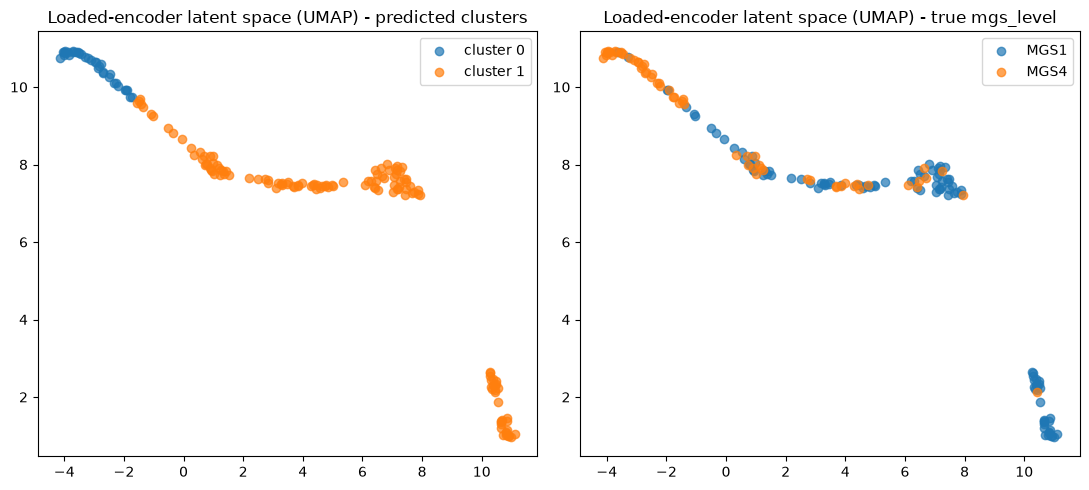

In [3]:
proj_loaded = umap.UMAP(n_components=8, random_state=5192).fit_transform(z_loaded)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for c in np.unique(y_pred_loaded):
    mask = y_pred_loaded == c
    axes[0].scatter(proj_loaded[mask, 0], proj_loaded[mask, 1], label=f'cluster {c}', alpha=0.7)
axes[0].set_title('Loaded-encoder latent space (UMAP) - predicted clusters')
axes[0].legend()

for c, name in enumerate(data['label_classes']):
    mask = data['y'] == c
    axes[1].scatter(proj_loaded[mask, 0], proj_loaded[mask, 1], label=name, alpha=0.7)
axes[1].set_title('Loaded-encoder latent space (UMAP) - true mgs_level')
axes[1].legend()
plt.tight_layout()
plt.show()

In [ ]:
# ---- Optional: pretrain the loaded encoder further as a standalone VAE
# (extra epochs, before clustering) - most workflows can skip straight from
# the load cell to the clustering cell above. ----
ae_loaded.args.epochs = 150    # additional epochs - edit as needed
ae_loaded.args.beta = 1.0
ae_loaded.args.distance = 'kl'  # ignored if CNCVAE._loss() no longer branches on kl/mmd
ae_loaded.train(x_num, x_bin)

z_finetuned = ae_loaded.predict(x_num, x_bin)
print('fine-tuned latent embedding:', z_finetuned.shape)

In [ ]:
# ---- Optional: re-cluster on top of the extra standalone pretraining above ----
dec_finetuned = DEC(ae_loaded, n_clusters=2)
y_pred_ft, y_proba_ft, centroids_ft, z_ft = dec_finetuned.fit(x_num, x_bin, y=data['y'])
acc, ari, nmi = calculate_metrics(data['y'], y_pred_ft)
print('acc={:.3f}  ari={:.3f}  nmi={:.3f}'.format(acc, ari, nmi))